# 06 Evaluation

- Computing metrics: MAPE and MdAPE
- Summarizing insights

- Output: metrics_summary.csv

## Set Up

- reloading ALL models produced up to 05_advanced models

In [1]:
# %pip install jinja2

import os, glob
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns, joblib
from sklearn.metrics import (r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error)

sns.set_theme(style="whitegrid")

TARGET, DATE = "ClosePrice", "CloseDate"
DATA    = sorted(glob.glob("../../data/cleaned_CRMLSSold*.csv"))[-1]
MODELS  = "../../models/week7_models.joblib"

B = joblib.load(MODELS)
registry, scaler = B["registry"], B["scaler"]
feature, structural, cat_cols, native = B["feature"], B["structural"], B["cat_cols"], B["native"]

TREES = joblib.load("../../models/week5_6_trees.joblib")["tree_registry"] #collects from 04 and 05 notebooks
print(f"loaded {len(registry)} boosters + {len(TREES)} DT/RF = {len(registry)+len(TREES)} models")

loaded 6 boosters + 11 DT/RF = 17 models


In [2]:
# rebuilding the splits

df = pd.read_csv(DATA, parse_dates=[DATE], low_memory=False)
TEST_MONTH   = df[DATE].dt.to_period("M").astype(str).max()
TRAIN_MONTHS = min(df[DATE].dt.to_period("M").nunique() - 1, 11)

def chrono_split(data, test_month=TEST_MONTH, window=TRAIN_MONTHS, date=DATE):
    m = data[date].dt.to_period("M"); tp = pd.Period(test_month, "M")
    return data[(m >= tp - window) & (m < tp)].copy(), data[m == tp].copy()

train_df, test_df = chrono_split(df)
test_df_full = test_df.copy()                                   # untrimmed set
lo, hi = train_df[TARGET].quantile(.01), train_df[TARGET].quantile(.99)
test_df = test_df[test_df[TARGET].between(lo, hi)].copy()        # 1/99 contract
print(f"test trimmed {len(test_df):,} | full June {len(test_df_full):,}")

#helpers
def rep_onehot(fr): return fr[feature]
def rep_scaled(fr): return scaler.transform(fr[feature])
def rep_native(fr):
    X = fr[native].copy()
    for c in cat_cols: X[c] = fr[c].astype("string").fillna("Unknown").astype(str)
    return X
REP = {"onehot": rep_onehot, "scaled": rep_scaled, "native": rep_native}

def mdape(yt, yp): return float(np.median(np.abs((np.asarray(yt) - yp) / np.asarray(yt))) * 100)
def metrics(yt, yp):
    yt = np.asarray(yt)
    return {"R2": r2_score(yt, yp), "MAE": mean_absolute_error(yt, yp),
            "RMSE": mean_squared_error(yt, yp) ** 0.5,
            "MAPE": mean_absolute_percentage_error(yt, yp) * 100, "MdAPE": mdape(yt, yp)}

test trimmed 12,570 | full June 12,837


In [3]:
#predictor map

predictors = {}

# 05 advanced models
for key, (est, rep) in registry.items():
    predictors[key] = (lambda e, r: (lambda fr: e.predict(REP[r](fr))))(est, rep)

# 04 tree models
def make_tree_pred(est, feats, target):
    def predict(fr):
        p = est.predict(fr[feats])
        return np.exp(p) if target == "log" else p
    return predict
for key, (est, feats, target) in TREES.items():
    predictors[key] = make_tree_pred(est, feats, target)

print(f"total models to evaluate: {len(predictors)}")   # 6 + 11 = 17

total models to evaluate: 17


# Overall Metrics 

- On all models created thus far (Linear, Random Forest, Decision Tree, Light GBM, XGBoost, CatBoost)

In [5]:
def evaluate(frame, label):
    yt = frame[TARGET].values
    rows, preds = [], {}
    for key, pfn in predictors.items():
        yp = pfn(frame); preds[key] = yp
        rows.append({"model": key, "eval_set": label, **metrics(yt, yp)})
    return pd.DataFrame(rows), preds

full_tbl, preds_full = evaluate(test_df_full, "full_June")
trim_tbl, preds_trim = evaluate(test_df,      "trimmed_1_99")
summary = (pd.concat([full_tbl, trim_tbl], ignore_index=True)
           .sort_values(["eval_set", "MdAPE"]).reset_index(drop=True))

summary.round(4).to_csv("../../results/metrics_summary.csv", index=False)

for label in ["full_June", "trimmed_1_99"]:
    sub = summary[summary["eval_set"] == label].drop(columns="eval_set")
    display(sub.style
            .format({"R2": "{:.3f}", "MAE": "${:,.0f}", "RMSE": "${:,.0f}",
                     "MAPE": "{:.2f}%", "MdAPE": "{:.2f}%"})
            .hide(axis="index").set_caption(label))
    
print("\nwrote ../../results/metrics_summary.csv")

model,R2,MAE,RMSE,MAPE,MdAPE
RandomForest|A-raw,0.552,"$231,221","$1,027,971",14.58%,8.08%
RandomForest|A+SchoolDistrict,0.553,"$229,912","$1,027,443",14.47%,8.10%
RandomForest|A-log,0.543,"$230,597","$1,038,152",13.75%,8.12%
RandomForest|A+FE+SchoolDistrict,0.550,"$232,975","$1,030,099",14.58%,8.18%
RandomForest|A+FE,0.549,"$234,879","$1,031,956",14.76%,8.27%
RandomForest|B-leaf5,0.543,"$237,572","$1,038,660",14.93%,8.35%
RandomForest|C-tuned,0.518,"$246,841","$1,066,709",15.98%,8.63%
LightGBM|B-tuned,0.605,"$219,109","$965,588",13.96%,8.71%
CatBoost|B-tuned,0.622,"$220,118","$943,799",14.10%,8.87%
CatBoost|A,0.604,"$231,534","$966,539",14.89%,9.56%


model,R2,MAE,RMSE,MAPE,MdAPE
RandomForest|A-log,0.877,"$157,728","$309,173",11.56%,7.86%
RandomForest|A-raw,0.879,"$159,770","$306,422",12.15%,7.87%
RandomForest|A+SchoolDistrict,0.881,"$158,375","$303,464",12.08%,7.88%
RandomForest|A+FE+SchoolDistrict,0.877,"$161,196","$309,500",12.28%,7.96%
RandomForest|A+FE,0.874,"$162,914","$312,214",12.41%,8.03%
RandomForest|B-leaf5,0.870,"$164,909","$317,816",12.48%,8.12%
RandomForest|C-tuned,0.863,"$170,299","$326,238",13.33%,8.39%
LightGBM|B-tuned,0.897,"$154,166","$282,790",12.03%,8.49%
CatBoost|B-tuned,0.894,"$157,355","$287,343",12.28%,8.65%
CatBoost|A,0.881,"$166,397","$303,588",13.02%,9.34%



wrote ../../results/metrics_summary.csv


### Interpret

- Comparing across all the models, the best is:

- Of the 1/99 trimmed sets:
    R^2: LightGBM|B-tuned (0.897), CatBoost|B-tuned (0.894)
    MAE: LightGBM|B-tuned ($154,166)
    RMSE: LightGBM|B-tuned ($282,790)
    MAPE: RandomForest|A-log (11.56%)
    MdAPE: RandomForest|A-log (7.86%)

- of the UNtrimmed test set
    R^2: CatBoost B-tuned (0.622)
    MAE: LightGBM B-tuned ($219,109)
    RMSE: CatBoost|B-tuned ($943,799)
    MAPE: RandomForest|A-log (13.75%)
    MdAPE: RandomForest (A) (8.08%)

- Major Takeaway: the best model isn't going to clear all metrics, it depends
    - Looking at the dollar metrics (R^2, RMSE, MAE), LightGBM and CatBoost are the strongest models
    - The % metrics (MAPE, MdAPE), RandomForest (A) is the strongest model

# Price Bands breakdown

Determining the better price band using the untrimmed data
- MdAPE ideally should be lower than higher


rows per band: {'<$500k': 1760, '$500k–1M': 5308, '$1M–2M': 3982, '$2M–5M': 1537, '$5M+': 250}


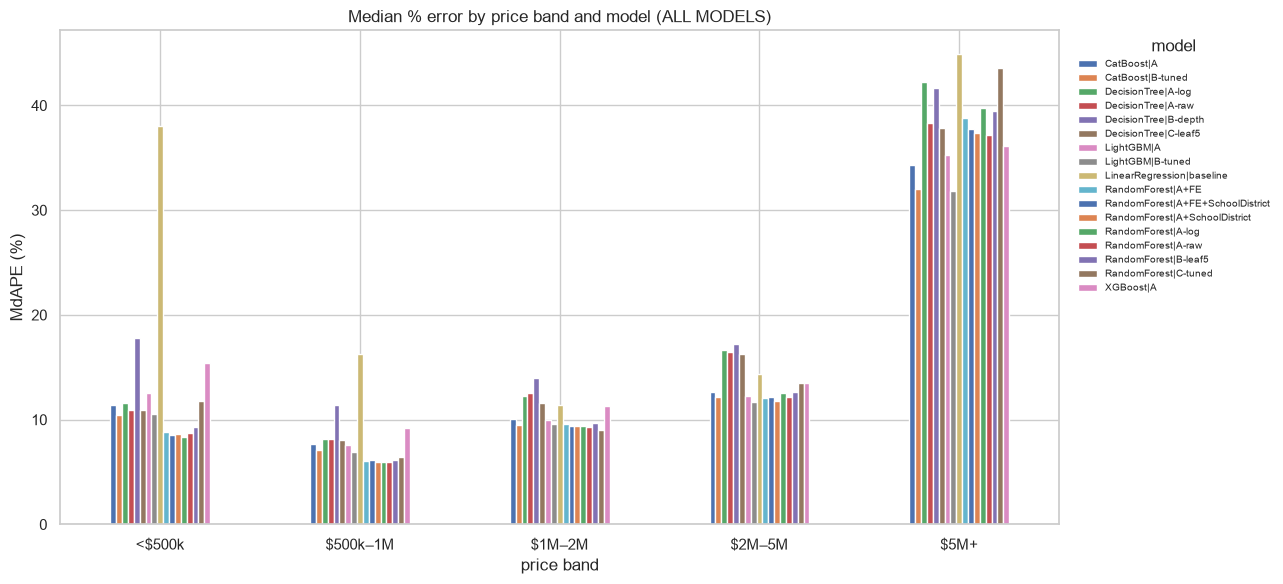

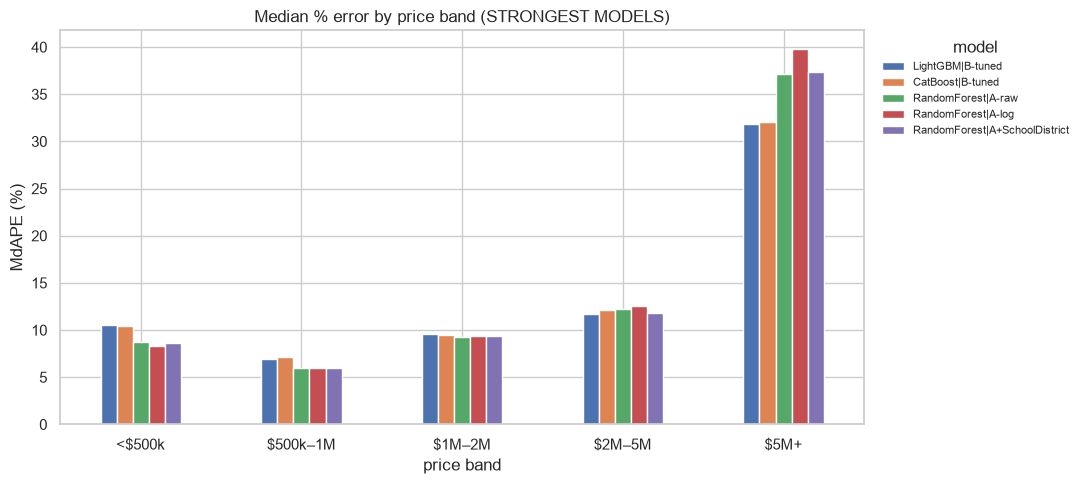

In [13]:
bands  = [(0, 5e5), (5e5, 1e6), (1e6, 2e6), (2e6, 5e6), (5e6, np.inf)]
labels = ["<$500k", "$500k–1M", "$1M–2M", "$2M–5M", "$5M+"]
yt = test_df_full[TARGET].values

band_rows = []
for key in preds_full:
    yp = preds_full[key]
    for (lo_, hi_), lab in zip(bands, labels):
        msk = (yt >= lo_) & (yt < hi_)
        if msk.sum() == 0: continue
        band_rows.append({"model": key, "band": lab, "n": int(msk.sum()),
                          "MdAPE": round(mdape(yt[msk], yp[msk]), 2),
                          "MAPE":  round(mean_absolute_percentage_error(yt[msk], yp[msk]) * 100, 2)})
band_df = pd.DataFrame(band_rows)
mdape_pivot = band_df.pivot(index="band", columns="model", values="MdAPE").reindex(labels)
print("\nrows per band:", band_df.groupby("band")["n"].first().reindex(labels).to_dict())

fig, ax = plt.subplots(figsize=(13, 6))
mdape_pivot.plot(kind="bar", ax=ax, rot=0)
ax.set_ylabel("MdAPE (%)"); ax.set_xlabel("price band")
ax.set_title("Median % error by price band and model (ALL MODELS)")
ax.legend(title="model", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=7, frameon=False)
plt.tight_layout()
plt.show()

STRONG = ["LightGBM|B-tuned", "CatBoost|B-tuned",
          "RandomForest|A-raw", "RandomForest|A-log", "RandomForest|A+SchoolDistrict"]
strong = [m for m in STRONG if m in mdape_pivot.columns]   # keep only ones present

fig, ax = plt.subplots(figsize=(11, 5))
mdape_pivot[strong].plot(kind="bar", ax=ax, rot=0)
ax.set_ylabel("MdAPE (%)"); ax.set_xlabel("price band")
ax.set_title("Median % error by price band (STRONGEST MODELS)")
ax.legend(title="model", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8, frameon=False)
plt.tight_layout(); plt.show()

### Interpret

Looking at the price band graph, RandomForest (A) does best on homes priced from < 500K to 2 Million. The Advanced models LightGBM and CatBoost perform the best on higher end homes.

Final result: the typical home costs are most accurately described by RandomForest, but where the home costs are significantly higher, the gradient boost models perform better.